In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("leetcode_questions.csv")

df.head()

# Preprocessing

median_success = df["Success Rate"].median()

df["HighSuccess"] = (df["Success Rate"] > median_success).astype(int)

df = df[["Difficulty Level", "Likes", "total submission", "HighSuccess"]]

df = df.dropna()

df = pd.get_dummies(df, columns=["Difficulty Level"])

X = df.drop("HighSuccess", axis=1)
y = df["HighSuccess"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [9]:
# Check tensorflow version

import tensorflow as tf
print(tf.__version__)

2.20.0


In [11]:
# Check version

import sys
print(sys.version)

3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


C:\Users\ojask\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5626 - loss: 0.6826 - val_accuracy: 0.6131 - val_loss: 0.6486
Epoch 2/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6430 - loss: 0.6309 - val_accuracy: 0.6429 - val_loss: 0.6231
Epoch 3/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6596 - loss: 0.6140 - val_accuracy: 0.6548 - val_loss: 0.6154
Epoch 4/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6622 - loss: 0.6068 - val_accuracy: 0.6488 - val_loss: 0.6117
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6616 - loss: 0.6033 - val_accuracy: 0.6756 - val_loss: 0.6097
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6705 - loss: 0.6005 - val_accuracy: 0.6756 - val_loss: 0.6066
Epoch 7/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6679 - loss: 0.5972 - val_accuracy: 0.6756 - val_loss: 0.6033
Epoch 8/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6705 - loss: 0.5961 - val_accuracy: 0.6756 - val_

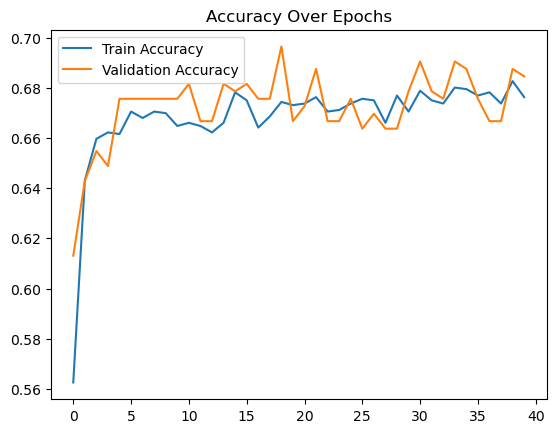

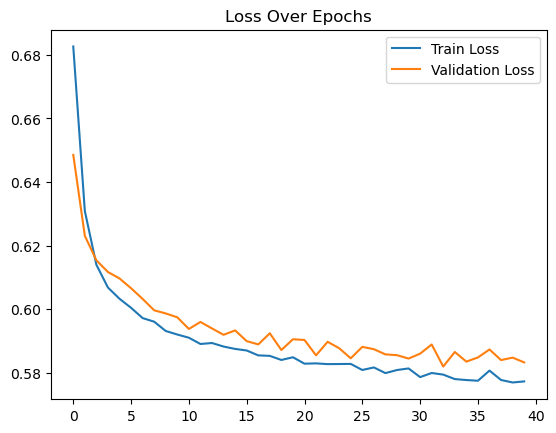

In [18]:
# Build Multi-Layer Perceptron

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the MLP model

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, y_val)
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

# Plot Training Curves

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Over Epochs")
plt.show()